In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# How do the activity scores compare per each downsample to the total?

## Getting step 1 map csv from duck db. 

In [27]:
step1_map = pd.read_csv("/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/NKX2-2/pipeline_test/no_err_corr/step1.csv")
step1_map = step1_map[["AD", "ADBC2", "RTBC", "HawkBCs"]]
step1_map

,AD,ADBC2,RTBC,HawkBCs
0,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCG...,TGTACA,ATACGATGATTAATAT,ATTCTCGCC
1,GCCCAGGACCTGGACGACGACACCTTCCAGGCCGGCATTCCCTTCA...,GTAATC,CCCCAGGCACTATAAG,CAGCGGTAT
2,ACCGACTTCATCGACGAGGAGGTGCTGATGAGCCTGGTGATCGAGA...,AACAAA,TGCTGAGTGTCGAATT,CCGATCTAT
3,GCCCAGGACCTGGCCGCCGCCAAGTTCCAGGCCGGCATTCCCTTCA...,ACGTAT,ACAGGCTGTCGCTACC,AGTGTGCGT
4,ACCGACGCCATCGACGAGGAGGTGGCCATGAGCGCCGTGATCGAGA...,ACGTTA,TGTGCCAATCAAGGCA,CCGTGATAC
...,...,...,...,...
1598,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCA...,AGAGTC,TGCAAATTTATCCCCA,AACCAGAAC
1599,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATCTATCCCA...,TATATA,CAAAATCGCGTATATA,AGCATCATC
1600,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCA...,TTAAGA,ATAATATAAAATCTTT,ACCTCGATT
1601,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCA...,CCGGTA,ACTCACTTTAAAGTTT,ACAAGTGGA


## Full results for time point 24

In [28]:
# Getting RT results alone
RPTR_BC_umi_counts_t24 = pd.read_csv("../../output/NKX2-2/TL4B2/puro_only/no_err_corr/trebl_experiment_r9_RTBC_Puro_Only_R1_T24_S106/r9_RTBC_Puro_Only_R1_T24_S106_simple_umi_counts.tsv", sep="\t")
RPTR_BC_umi_counts_t24 = RPTR_BC_umi_counts_t24.rename(columns={"count": "RT_umi_count"})
RPTR_BC_umi_counts_t24

,RTBC,RT_umi_count
0,CGAGTTCGTGATACAA,98569
1,ATTTTTGAATTTTTAT,36080
2,AAATTGACAAAGAGAC,32763
3,GCTTAATGTTGGATAG,30176
4,TTGACTATAATACATA,29009
...,...,...
47062,GGTTACAGAATCATAA,1
47063,TGTTGCGAGAAATGTA,1
47064,ACTTCTTCAAGTCGTT,1
47065,TTTGCCTAAATCAATT,1


In [29]:
# Getting AD results alone
AD_BC_counts_t24 = pd.read_csv("../../output/NKX2-2/TL4B2/puro_only/no_err_corr/trebl_experiment_a9_ADBC_Puro_Only_R1_T24_S98/a9_ADBC_Puro_Only_R1_T24_S98_simple_umi_counts.tsv", sep="\t")
AD_BC_counts_t24 = AD_BC_counts_t24.rename(columns={"count": "AD_umi_count"})
AD_BC_counts_t24

,ADBC2,HawkBCs,AD_umi_count
0,CCATAA,CACCGATTG,71588
1,GATAAG,CATTCCAAG,60855
2,TAGTTG,ACGACCATA,53672
3,ATGATC,CAATCTCTC,52310
4,ACGACA,CAAGGAACA,42827
...,...,...,...
39781,CATTAC,CAATTTCTC,1
39782,ATGGCA,CAGATATGG,1
39783,TAGCTA,ATCACCGCC,1
39784,CTATAC,CAGATATGG,1


In [30]:
# Adding RT results to step 1 map
step1_map_with_RPTR_BC_t24 = pd.merge(step1_map, RPTR_BC_umi_counts_t24, how="left")
step1_map_with_RPTR_BC_t24

,AD,ADBC2,RTBC,HawkBCs,RT_umi_count
0,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCG...,TGTACA,ATACGATGATTAATAT,ATTCTCGCC,1468.0
1,GCCCAGGACCTGGACGACGACACCTTCCAGGCCGGCATTCCCTTCA...,GTAATC,CCCCAGGCACTATAAG,CAGCGGTAT,1313.0
2,ACCGACTTCATCGACGAGGAGGTGCTGATGAGCCTGGTGATCGAGA...,AACAAA,TGCTGAGTGTCGAATT,CCGATCTAT,9.0
3,GCCCAGGACCTGGCCGCCGCCAAGTTCCAGGCCGGCATTCCCTTCA...,ACGTAT,ACAGGCTGTCGCTACC,AGTGTGCGT,655.0
4,ACCGACGCCATCGACGAGGAGGTGGCCATGAGCGCCGTGATCGAGA...,ACGTTA,TGTGCCAATCAAGGCA,CCGTGATAC,26.0
...,...,...,...,...,...
1598,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCA...,AGAGTC,TGCAAATTTATCCCCA,AACCAGAAC,856.0
1599,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATCTATCCCA...,TATATA,CAAAATCGCGTATATA,AGCATCATC,NaN
1600,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCA...,TTAAGA,ATAATATAAAATCTTT,ACCTCGATT,10799.0
1601,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCA...,CCGGTA,ACTCACTTTAAAGTTT,ACAAGTGGA,23.0


In [31]:
# Adding AD results to step 1 map
step1_map_with_RPTR_BC_AD_BC_t24 = pd.merge(step1_map_with_RPTR_BC_t24, AD_BC_counts_t24, how="left")
step1_map_with_RPTR_BC_AD_BC_t24

,AD,ADBC2,RTBC,HawkBCs,RT_umi_count,AD_umi_count
0,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCG...,TGTACA,ATACGATGATTAATAT,ATTCTCGCC,1468.0,1711.0
1,GCCCAGGACCTGGACGACGACACCTTCCAGGCCGGCATTCCCTTCA...,GTAATC,CCCCAGGCACTATAAG,CAGCGGTAT,1313.0,4251.0
2,ACCGACTTCATCGACGAGGAGGTGCTGATGAGCCTGGTGATCGAGA...,AACAAA,TGCTGAGTGTCGAATT,CCGATCTAT,9.0,2.0
3,GCCCAGGACCTGGCCGCCGCCAAGTTCCAGGCCGGCATTCCCTTCA...,ACGTAT,ACAGGCTGTCGCTACC,AGTGTGCGT,655.0,907.0
4,ACCGACGCCATCGACGAGGAGGTGGCCATGAGCGCCGTGATCGAGA...,ACGTTA,TGTGCCAATCAAGGCA,CCGTGATAC,26.0,NaN
...,...,...,...,...,...,...
1598,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCA...,AGAGTC,TGCAAATTTATCCCCA,AACCAGAAC,856.0,1013.0
1599,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATCTATCCCA...,TATATA,CAAAATCGCGTATATA,AGCATCATC,NaN,NaN
1600,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCA...,TTAAGA,ATAATATAAAATCTTT,ACCTCGATT,10799.0,2178.0
1601,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCA...,CCGGTA,ACTCACTTTAAAGTTT,ACAAGTGGA,23.0,12.0


In [32]:
# Removing nulls from step 1 map
step1_map_with_RPTR_BC_AD_BC_no_nulls_t24 = step1_map_with_RPTR_BC_AD_BC_t24.dropna()

# Adding '_full' suffix to the last two columns
step1_map_with_RPTR_BC_AD_BC_no_nulls_t24 = step1_map_with_RPTR_BC_AD_BC_no_nulls_t24.rename(
    columns={
        step1_map_with_RPTR_BC_AD_BC_no_nulls_t24.columns[-2]: step1_map_with_RPTR_BC_AD_BC_no_nulls_t24.columns[-2] + '_full',
        step1_map_with_RPTR_BC_AD_BC_no_nulls_t24.columns[-1]: step1_map_with_RPTR_BC_AD_BC_no_nulls_t24.columns[-1] + '_full'
    }
)

# Creating a copy and calculating activity
step1_map_with_RPTR_BC_AD_BC_no_nulls_full_t24 = step1_map_with_RPTR_BC_AD_BC_no_nulls_t24.copy(deep=True)
step1_map_with_RPTR_BC_AD_BC_no_nulls_full_t24["activity_full"] = (
    step1_map_with_RPTR_BC_AD_BC_no_nulls_full_t24["RT_umi_count_full"].astype(int) /
    step1_map_with_RPTR_BC_AD_BC_no_nulls_full_t24["AD_umi_count_full"].astype(int)
)

step1_map_with_RPTR_BC_AD_BC_no_nulls_full_t24

,AD,ADBC2,RTBC,HawkBCs,RT_umi_count_full,AD_umi_count_full,activity_full
0,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCG...,TGTACA,ATACGATGATTAATAT,ATTCTCGCC,1468.0,1711.0,0.857978
1,GCCCAGGACCTGGACGACGACACCTTCCAGGCCGGCATTCCCTTCA...,GTAATC,CCCCAGGCACTATAAG,CAGCGGTAT,1313.0,4251.0,0.308869
2,ACCGACTTCATCGACGAGGAGGTGCTGATGAGCCTGGTGATCGAGA...,AACAAA,TGCTGAGTGTCGAATT,CCGATCTAT,9.0,2.0,4.500000
3,GCCCAGGACCTGGCCGCCGCCAAGTTCCAGGCCGGCATTCCCTTCA...,ACGTAT,ACAGGCTGTCGCTACC,AGTGTGCGT,655.0,907.0,0.722161
7,GCCCAGGACCTGGCCGCCGCCACCGCCCAGGCCGGCATTCCCTTCA...,CTCAGA,TTCAGAGGCATATGGA,AATCGTGCC,92.0,48.0,1.916667
...,...,...,...,...,...,...,...
1591,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCA...,TAAAGA,TAATTATCATACTAAA,ACAACCTGC,10994.0,2685.0,4.094600
1596,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCA...,TCAAGG,TGATGTTGAAAACTCA,ACATGGTCA,1559.0,1137.0,1.371152
1598,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCA...,AGAGTC,TGCAAATTTATCCCCA,AACCAGAAC,856.0,1013.0,0.845015
1600,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCA...,TTAAGA,ATAATATAAAATCTTT,ACCTCGATT,10799.0,2178.0,4.958219


# Full results for time  = 4

In [33]:
# Getting RT results alone
RPTR_BC_umi_counts_t4 = pd.read_csv("../../output/NKX2-2/TL4B2/puro_only/no_err_corr/trebl_experiment_r5_RTBC_Puro_Only_R1_T4_S102/r5_RTBC_Puro_Only_R1_T4_S102_simple_umi_counts.tsv", sep="\t")
RPTR_BC_umi_counts_t4 = RPTR_BC_umi_counts_t4.rename(columns={"count": "RT_umi_count"})

# Getting AD results alone
AD_BC_counts_t4 = pd.read_csv("../../output/NKX2-2/TL4B2/puro_only/no_err_corr/trebl_experiment_a5_ADBC_Puro_Only_R1_T4_S94/a5_ADBC_Puro_Only_R1_T4_S94_simple_umi_counts.tsv", sep="\t")
AD_BC_counts_t4 = AD_BC_counts_t4.rename(columns={"count": "AD_umi_count"})

# Adding RT results to step 1 map
step1_map_with_RPTR_BC_t4 = pd.merge(step1_map, RPTR_BC_umi_counts_t4, how="left")

# Adding AD results to step 1 map
step1_map_with_RPTR_BC_AD_BC_t4 = pd.merge(step1_map_with_RPTR_BC_t4, AD_BC_counts_t4, how="left")

# Removing nulls from step 1 map
step1_map_with_RPTR_BC_AD_BC_no_nulls_t4 = step1_map_with_RPTR_BC_AD_BC_t4.dropna()

# Adding '_full' suffix to the last two columns
step1_map_with_RPTR_BC_AD_BC_no_nulls_t4 = step1_map_with_RPTR_BC_AD_BC_no_nulls_t4.rename(
    columns={
        step1_map_with_RPTR_BC_AD_BC_no_nulls_t4.columns[-2]: step1_map_with_RPTR_BC_AD_BC_no_nulls_t4.columns[-2] + '_full',
        step1_map_with_RPTR_BC_AD_BC_no_nulls_t4.columns[-1]: step1_map_with_RPTR_BC_AD_BC_no_nulls_t4.columns[-1] + '_full'
    }
)

# Creating a copy and calculating activity
step1_map_with_RPTR_BC_AD_BC_no_nulls_full_t4 = step1_map_with_RPTR_BC_AD_BC_no_nulls_t4.copy(deep=True)
step1_map_with_RPTR_BC_AD_BC_no_nulls_full_t4["activity_full"] = (
    step1_map_with_RPTR_BC_AD_BC_no_nulls_full_t4["RT_umi_count_full"].astype(int) /
    step1_map_with_RPTR_BC_AD_BC_no_nulls_full_t4["AD_umi_count_full"].astype(int)
)

step1_map_with_RPTR_BC_AD_BC_no_nulls_full_t4

,AD,ADBC2,RTBC,HawkBCs,RT_umi_count_full,AD_umi_count_full,activity_full
0,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCG...,TGTACA,ATACGATGATTAATAT,ATTCTCGCC,82.0,299.0,0.274247
1,GCCCAGGACCTGGACGACGACACCTTCCAGGCCGGCATTCCCTTCA...,GTAATC,CCCCAGGCACTATAAG,CAGCGGTAT,127.0,2689.0,0.047229
2,ACCGACTTCATCGACGAGGAGGTGCTGATGAGCCTGGTGATCGAGA...,AACAAA,TGCTGAGTGTCGAATT,CCGATCTAT,5.0,5.0,1.000000
3,GCCCAGGACCTGGCCGCCGCCAAGTTCCAGGCCGGCATTCCCTTCA...,ACGTAT,ACAGGCTGTCGCTACC,AGTGTGCGT,46.0,173.0,0.265896
7,GCCCAGGACCTGGCCGCCGCCACCGCCCAGGCCGGCATTCCCTTCA...,CTCAGA,TTCAGAGGCATATGGA,AATCGTGCC,86.0,29.0,2.965517
...,...,...,...,...,...,...,...
1591,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCA...,TAAAGA,TAATTATCATACTAAA,ACAACCTGC,10116.0,2349.0,4.306513
1596,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCA...,TCAAGG,TGATGTTGAAAACTCA,ACATGGTCA,205.0,385.0,0.532468
1598,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCA...,AGAGTC,TGCAAATTTATCCCCA,AACCAGAAC,53.0,227.0,0.233480
1600,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCA...,TTAAGA,ATAATATAAAATCTTT,ACCTCGATT,7466.0,1323.0,5.643235


# For each downsample, save the activity scores

In [34]:
import os
import warnings
warnings.filterwarnings('ignore')
import tqdm
# Define the base directory
base_dir = "../../output/NKX2-2/downsampling/"

# Iterate through all folders in the base directory
for folder in tqdm.tqdm(os.listdir(base_dir)):
    folder_path = os.path.join(base_dir, folder)
    if os.path.isdir(folder_path) and "RTBC" in folder:
        # print(folder)
        # Process the RPTR_BC_umi_counts file
        umi_counts_path = next(
            (os.path.join(folder_path, file) for file in os.listdir(folder_path) if file.endswith("simple_umi_counts.tsv")),
            None
        )
        if umi_counts_path is None:
            continue
        RPTR_BC_umi_counts = pd.read_csv(umi_counts_path, sep="\t", encoding='latin-1')
        RPTR_BC_umi_counts = RPTR_BC_umi_counts.rename(columns={"count": "RT_umi_count"})

        # Merge with step1_map
        step1_map_with_RPTR_BC = pd.merge(step1_map, RPTR_BC_umi_counts, how="left")

        if "r9" in folder:
            AD_BC_counts = AD_BC_counts_t24
        else:
            AD_BC_counts = AD_BC_counts_t4

        # Merge with AD_BC_counts
        step1_map_with_RPTR_BC_AD_BC = pd.merge(step1_map_with_RPTR_BC, AD_BC_counts, how="left")

        # Remove nulls
        step1_map_with_RPTR_BC_AD_BC_no_nulls = step1_map_with_RPTR_BC_AD_BC.dropna()

        step1_map_with_RPTR_BC_AD_BC_no_nulls = step1_map_with_RPTR_BC_AD_BC_no_nulls.rename(
            columns={step1_map_with_RPTR_BC_AD_BC_no_nulls.columns[-2]: step1_map_with_RPTR_BC_AD_BC_no_nulls.columns[-2] + '_downsampled',
                    step1_map_with_RPTR_BC_AD_BC_no_nulls.columns[-1]: step1_map_with_RPTR_BC_AD_BC_no_nulls.columns[-1] + '_downsampled'}
        )

        step1_map_with_RPTR_BC_AD_BC_no_nulls["activity_downsampled"] = step1_map_with_RPTR_BC_AD_BC_no_nulls["RT_umi_count_downsampled"].astype(int) / step1_map_with_RPTR_BC_AD_BC_no_nulls["AD_umi_count_downsampled"].astype(int)

        if "r9" in folder:
            step1_map_with_RPTR_BC_AD_BC_no_nulls = pd.merge(
                step1_map_with_RPTR_BC_AD_BC_no_nulls_full_t24,
                step1_map_with_RPTR_BC_AD_BC_no_nulls,
                on=["AD", "ADBC2", "RTBC", "HawkBCs"],
                how="inner",
            )
        else:
            step1_map_with_RPTR_BC_AD_BC_no_nulls = pd.merge(
                step1_map_with_RPTR_BC_AD_BC_no_nulls_full_t4,
                step1_map_with_RPTR_BC_AD_BC_no_nulls,
                on=["AD", "ADBC2", "RTBC", "HawkBCs"],
                how="inner",
            )

        # Save the processed file as a CSV
        output_path = os.path.join(folder_path, "processed_step1_map.csv")
        step1_map_with_RPTR_BC_AD_BC_no_nulls.to_csv(output_path, index=False)
        #print(f"Processed file saved to: {output_path}")

100%|██████████| 122/122 [00:02<00:00, 49.84it/s]


# Calculating correlations of each downsample with full

In [36]:
import pandas as pd
import os
from scipy.stats import pearsonr, spearmanr

# Initialize an empty list to store correlation results
correlation_results = []

# Loop through the base directory
for folder in tqdm.tqdm(os.listdir(base_dir)):
    folder_path = os.path.join(base_dir, folder)
    if os.path.isdir(folder_path) and "RTBC" in folder:
        processed_file_path = os.path.join(folder_path, "processed_step1_map.csv")
        if os.path.exists(processed_file_path):
            # Read the processed_step1_map.csv file
            df = pd.read_csv(processed_file_path)
            
            # Check if the required columns exist
            if "activity_full" in df.columns and "activity_downsampled" in df.columns:
                # Calculate Pearson and Spearman correlations
                pearson_corr, _ = pearsonr(df["activity_full"], df["activity_downsampled"])
                spearman_corr, _ = spearmanr(df["activity_full"], df["activity_downsampled"])
                
                # Append the results to the list
                correlation_results.append({
                    "folder_path": folder_path,
                    "pearson_corr": pearson_corr,
                    "spearman_corr": spearman_corr,
                    "num_rows": len(df)  # Track the number of rows
                })

                # Create scatterplot
                fig, ax = plt.subplots(figsize=(6,6), dpi=300)
                sns.set_context('talk')
                ax.scatter(df["activity_full"], df["activity_downsampled"], alpha=0.5, edgecolor = 'none', s = 5)
                ax.set_xscale('log')
                ax.set_yscale('log')
                ax.set_xlabel("Activity Full")
                ax.set_ylabel("Activity Downsampled")
                ax.set_title("Activity Full vs Activity Downsampled")
                ax.grid(False)
                sns.despine(ax=ax)

                # Add correlations as text
                ax.text(0.05, 0.95,
                        f"Pearson: {pearson_corr:.2f}\nSpearman: {spearman_corr:.2f}",
                        transform=ax.transAxes, fontsize=12, verticalalignment='top')

                # Save figure
                scatterplot_path = os.path.join(folder_path, "activity_scatterplot.png")
                plt.savefig(scatterplot_path, bbox_inches='tight')
                plt.close(fig)

# Convert the results into a DataFrame
correlation_df = pd.DataFrame(correlation_results)

# Display the correlation DataFrame
correlation_df

100%|██████████| 122/122 [00:45<00:00,  2.66it/s]


,folder_path,pearson_corr,spearman_corr,num_rows
0,../../output/NKX2-2/downsampling/trebl_experim...,0.999893,0.978535,888
1,../../output/NKX2-2/downsampling/trebl_experim...,0.999180,0.963098,884
2,../../output/NKX2-2/downsampling/trebl_experim...,0.999676,0.965369,871
3,../../output/NKX2-2/downsampling/trebl_experim...,0.999870,0.991523,899
4,../../output/NKX2-2/downsampling/trebl_experim...,0.999070,0.939599,840
5,../../output/NKX2-2/downsampling/trebl_experim...,0.999860,0.983852,891
6,../../output/NKX2-2/downsampling/trebl_experim...,0.999542,0.972719,880
7,../../output/NKX2-2/downsampling/trebl_experim...,0.999859,0.981399,886
8,../../output/NKX2-2/downsampling/trebl_experim...,0.999959,0.995374,896
9,../../output/NKX2-2/downsampling/trebl_experim...,0.999817,0.980775,888


In [37]:
correlation_df['num_splits'] = correlation_df['folder_path'].str.extract(r'_(\d+)_chunks')#.astype(int)

correlation_df.loc[correlation_df['folder_path'].str.contains('_75'), 'num_splits'] = 4 / 3
correlation_df.loc[correlation_df['folder_path'].str.contains('_1_chunk'), 'num_splits'] = 1

correlation_df

,folder_path,pearson_corr,spearman_corr,num_rows,num_splits
0,../../output/NKX2-2/downsampling/trebl_experim...,0.999893,0.978535,888,5
1,../../output/NKX2-2/downsampling/trebl_experim...,0.999180,0.963098,884,20
2,../../output/NKX2-2/downsampling/trebl_experim...,0.999676,0.965369,871,10
3,../../output/NKX2-2/downsampling/trebl_experim...,0.999870,0.991523,899,4
4,../../output/NKX2-2/downsampling/trebl_experim...,0.999070,0.939599,840,20
5,../../output/NKX2-2/downsampling/trebl_experim...,0.999860,0.983852,891,8
6,../../output/NKX2-2/downsampling/trebl_experim...,0.999542,0.972719,880,20
7,../../output/NKX2-2/downsampling/trebl_experim...,0.999859,0.981399,886,4
8,../../output/NKX2-2/downsampling/trebl_experim...,0.999959,0.995374,896,3
9,../../output/NKX2-2/downsampling/trebl_experim...,0.999817,0.980775,888,10


In [40]:
correlation_df["percent_reads"] = 100 / correlation_df["num_splits"].astype(float)
correlation_df["time"] = correlation_df["folder_path"].str.extract("_T(\d+)_").astype(int)
correlation_df

,folder_path,pearson_corr,spearman_corr,num_rows,num_splits,percent_reads,time
0,../../output/NKX2-2/downsampling/trebl_experim...,0.999893,0.978535,888,5,20.000000,4
1,../../output/NKX2-2/downsampling/trebl_experim...,0.999180,0.963098,884,20,5.000000,24
2,../../output/NKX2-2/downsampling/trebl_experim...,0.999676,0.965369,871,10,10.000000,4
3,../../output/NKX2-2/downsampling/trebl_experim...,0.999870,0.991523,899,4,25.000000,24
4,../../output/NKX2-2/downsampling/trebl_experim...,0.999070,0.939599,840,20,5.000000,4
5,../../output/NKX2-2/downsampling/trebl_experim...,0.999860,0.983852,891,8,12.500000,24
6,../../output/NKX2-2/downsampling/trebl_experim...,0.999542,0.972719,880,20,5.000000,24
7,../../output/NKX2-2/downsampling/trebl_experim...,0.999859,0.981399,886,4,25.000000,4
8,../../output/NKX2-2/downsampling/trebl_experim...,0.999959,0.995374,896,3,33.333333,24
9,../../output/NKX2-2/downsampling/trebl_experim...,0.999817,0.980775,888,10,10.000000,24


In [41]:
# Filter data for time = 5 and time = 30
correlation_df_4 = correlation_df[correlation_df["time"] == 4]
correlation_df_24 = correlation_df[correlation_df["time"] == 24]


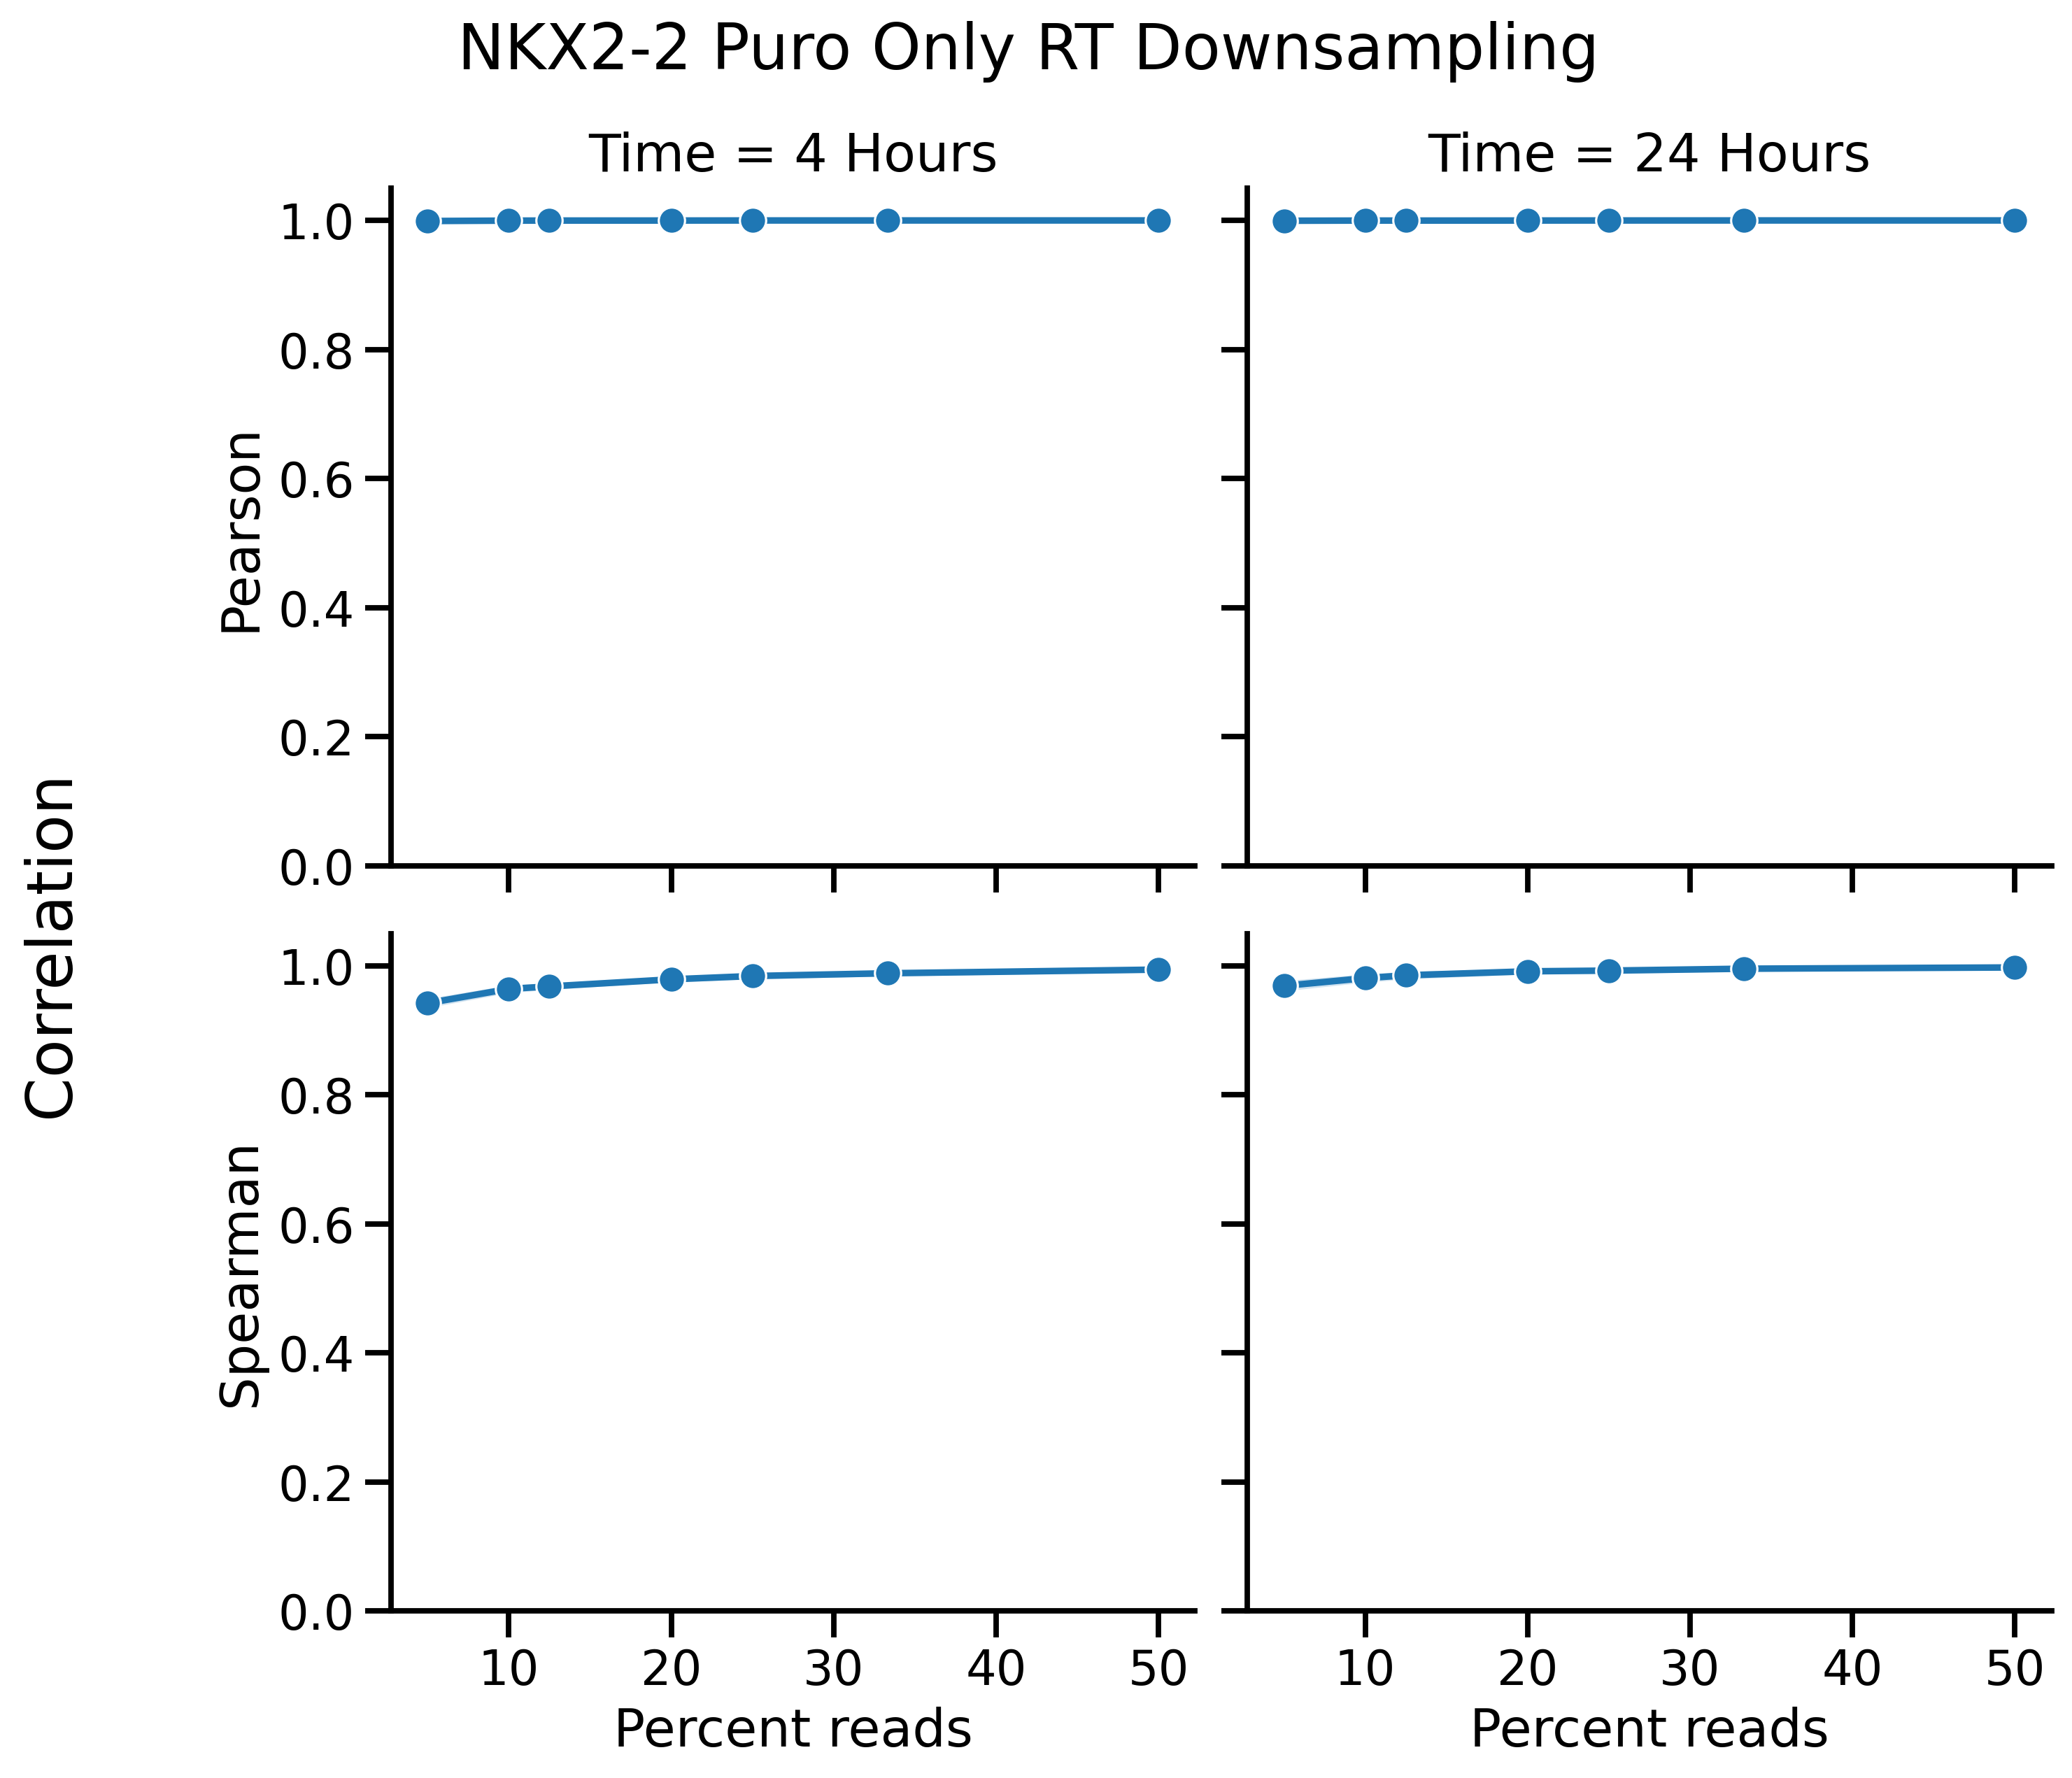

In [52]:
fig, axes = plt.subplots(
    2, 2, figsize=(10,8), dpi=300, sharex=True, sharey='row'
)
sns.set_context("talk")

# ---------- Pearson (row 0) ----------
sns.lineplot(
    data=correlation_df_4,
    x="percent_reads",
    y="pearson_corr",
    estimator="median",
    errorbar=("sd"),
    marker="o",
    ax=axes[0, 0]
)
axes[0, 0].set_title("Time = 4 Hours")
axes[0, 0].set_ylabel("Pearson")
axes[0, 0].set_xlabel("")
sns.despine(ax=axes[0, 0])

sns.lineplot(
    data=correlation_df_24,
    x="percent_reads",
    y="pearson_corr",
    estimator="median",
    errorbar=("sd"),
    marker="o",
    ax=axes[0, 1]
)
axes[0, 1].set_title("Time = 24 Hours")
axes[0, 1].set_ylabel("")
axes[0, 1].set_xlabel("")
sns.despine(ax=axes[0, 1])

# ---------- Spearman (row 1) ----------
sns.lineplot(
    data=correlation_df_4,
    x="percent_reads",
    y="spearman_corr",
    estimator="median",
    errorbar=("sd"),
    marker="o",
    ax=axes[1, 0]
)
axes[1, 0].set_ylabel("Spearman")
axes[1, 0].set_xlabel("Percent reads")
sns.despine(ax=axes[1, 0])

sns.lineplot(
    data=correlation_df_24,
    x="percent_reads",
    y="spearman_corr",
    estimator="median",
    errorbar=("sd"),
    marker="o",
    ax=axes[1, 1]
)
axes[1, 1].set_ylabel("")
axes[1, 1].set_xlabel("Percent reads")
sns.despine(ax=axes[1, 1])
fig.align_ylabels(axes)
fig.supylabel("Correlation")
plt.tight_layout(pad = 0.5)

for ax in axes.flatten():
    ax.set_ylim(0,1.05)

plt.suptitle("NKX2-2 Puro Only RT Downsampling", y = 1.05)
plt.show()